# Partial Cross-Entropy Loss for Point-Supervised Remote Sensing Segmentation
### DeepGlobe Land Cover Classification

This notebook implements and evaluates a point-supervised segmentation pipeline:

1. **Partial (Focal) Cross-Entropy loss** — trains using only sparse point labels
2. **Point-label simulation** — samples simulated points from DeepGlobe's full masks
3. **Experiments** — point density and sampling-strategy ablations
4. **Technical report inputs** — result tables/plots referenced in `technical_report.md`

All reusable logic lives in `src/` (`data_utils.py`, `point_sampler.py`, `losses.py`,
`dataset.py`, `model.py`, `train.py`, `metrics.py`, `experiments.py`) — this notebook
is the orchestration / demonstration layer.

> **Note on data:** this notebook ships with a small **synthetic** DeepGlobe-like
> dataset (`sample_data/`) so every cell runs end-to-end without external downloads.
> To run on the real dataset, download it from Kaggle and point `DATA_ROOT` in
> Section 1 to the real `images/` and `masks/` folders — no other code changes
> are needed, since the loader only assumes the DeepGlobe RGB-mask color scheme
> and `*_sat.jpg` / `*_mask.png` naming convention.


## 1. Load Data

### Using the real DeepGlobe dataset
1. Download from Kaggle:
   `kaggle datasets download -d balraj98/deepglobe-land-cover-classification-dataset`
2. Unzip so you have parallel `images/*_sat.jpg` and `masks/*_mask.png` files.
3. Set `DATA_ROOT` below to that folder, and set `USE_SYNTHETIC_DATA = False`.

### Using the bundled synthetic sample (default, for smoke-testing this notebook)
Leave `USE_SYNTHETIC_DATA = True`. The synthetic generator (`src/make_synthetic_data.py`)
creates a handful of DeepGlobe-*colored* image/mask pairs with the same 7-class RGB
scheme, tiling behavior, and file layout as the real dataset — enough to validate that
every step below runs correctly before pointing at the real ~2.9 GB Kaggle download.


In [3]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.6 MB/s eta 0:00:00


In [4]:
import sys
import os
# The exact path might vary slightly depending on what you named the dataset. 
# Check the right-hand 'Data' panel to verify the exact folder name!
src_path = '/kaggle/input/datasets/huzaifa10/sourcecode/src' 
if src_path not in sys.path:
    sys.path.append(src_path)
print("Path added! Current sys.path:", sys.path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data_utils import (
    rgb_mask_to_class_id, class_id_to_rgb_mask, tile_image_and_mask,
    CLASS_NAMES, CLASS_COLORS, NUM_CLASSES, IGNORE_INDEX,
)
from point_sampler import random_point_sample, class_balanced_point_sample
from dataset import PointSupervisedTileDataset, FullMaskTileDataset
from losses import PartialFocalCE, DenseFocalCE
from model import build_model
from metrics import ConfusionMatrixMeter
from train import TrainConfig, fit
from experiments import run_point_density_experiment, run_sampling_strategy_experiment

torch.manual_seed(0)
np.random.seed(0)

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Path added! Current sys.path: ['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/kaggle/src', '/kaggle/input/datasets/huzaifa10/sourcecode/src']
Torch: 2.10.0+cu128 | CUDA available: True


In [5]:
USE_SYNTHETIC_DATA = False     # <-- set False once you've downloaded the real dataset
DATA_ROOT = r"/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset"  # <-- point at real DeepGlobe folder when USE_SYNTHETIC_DATA=False
TILE_SIZE = 512                # 512 recommended for the real 2448x2448 images; smaller here for speed

if USE_SYNTHETIC_DATA and not os.path.exists(os.path.join(DATA_ROOT, "images")):
    from make_synthetic_data import generate_dataset
    generate_dataset(DATA_ROOT, n_images=8, size=600)

if USE_SYNTHETIC_DATA:
    image_dir = os.path.join(DATA_ROOT, "images")
    mask_dir = os.path.join(DATA_ROOT, "masks")
else:
    image_dir = os.path.join(DATA_ROOT, "train")
    mask_dir = os.path.join(DATA_ROOT, "train")

image_files = sorted([f for f in os.listdir(image_dir) if f.endswith("_sat.jpg")])
print(f"Found {len(image_files)} source images in {image_dir}")



Found 803 source images in /kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset/train


## 2. Mask Decoding + Tiling

Decode each RGB color-coded mask into an integer class-ID mask, then split large
images into smaller tiles for training (see `src/data_utils.py`).

**Train/val split is done at the source-image level** (before tiling) to avoid
patches from the same original image leaking across the split.


In [6]:
from PIL import Image

def load_pair(img_name):
    stem = img_name.split("_sat")[0]
    img = np.array(Image.open(os.path.join(image_dir, img_name)).convert("RGB"))
    mask_name = [f for f in os.listdir(mask_dir) if f.startswith(stem) and f.endswith("_mask.png")][0]
    mask_rgb = np.array(Image.open(os.path.join(mask_dir, mask_name)).convert("RGB"))
    class_id_mask = rgb_mask_to_class_id(mask_rgb)
    return img, class_id_mask

# To prevent Out-Of-Memory crashes, we limit the dataset to 60 images 
# which will generate ~1,500 tiles (fits comfortably in most RAM)
subset = image_files[:60] 

# 70/15/15 split at the SOURCE-IMAGE level
n = len(subset)
n_train = max(1, int(0.7 * n))
n_val = max(1, int(0.15 * n))

train_files = subset[:n_train]
val_files = subset[n_train:n_train + n_val]
test_files = subset[n_train + n_val:]
print(f"source images -> train={len(train_files)} val={len(val_files)} test={len(test_files)}")


def build_tiles(file_list):
    tiles = []
    for f in file_list:
        img, cid = load_pair(f)
        tiles.extend(tile_image_and_mask(img, cid, tile_size=TILE_SIZE, stride=TILE_SIZE, drop_partial=True))
    return tiles

train_tiles = build_tiles(train_files)
val_tiles = build_tiles(val_files)
test_tiles = build_tiles(test_files) if test_files else val_tiles

print(f"tile counts -> train={len(train_tiles)} val={len(val_tiles)} test={len(test_tiles)}")


source images -> train=42 val=9 test=9
tile counts -> train=672 val=144 test=144


## 3. Visualize: Image / Full Mask / Simulated Points

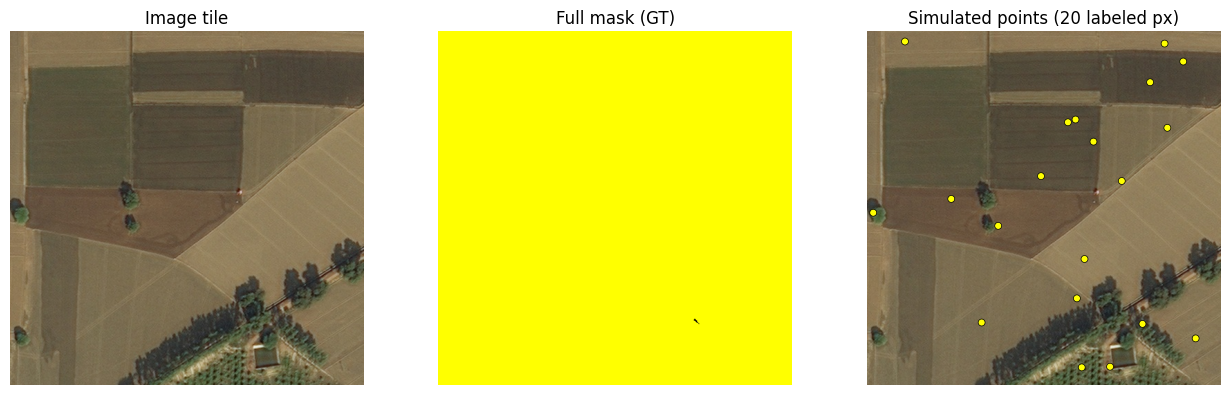

In [8]:
demo_img, demo_mask = train_tiles[0]
sparse_label, mask_labeled = random_point_sample(demo_mask, n_points_per_class=20, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(demo_img); axes[0].set_title("Image tile"); axes[0].axis("off")
axes[1].imshow(class_id_to_rgb_mask(demo_mask)); axes[1].set_title("Full mask (GT)"); axes[1].axis("off")

axes[2].imshow(demo_img)
ys, xs = np.where(mask_labeled == 1)
colors = [tuple(c / 255 for c in CLASS_COLORS[demo_mask[y, x]]) for y, x in zip(ys, xs)]
axes[2].scatter(xs, ys, c=colors, s=25, edgecolors="black", linewidths=0.5)
axes[2].set_title(f"Simulated points ({int(mask_labeled.sum())} labeled px)")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## 4. Partial Focal CE Loss — Sanity Check

Quick numerical check: loss should be **higher** for random logits than for
logits that are (artificially) forced to strongly favor the correct class,
and should only depend on labeled pixels.


In [9]:
criterion = PartialFocalCE(num_classes=NUM_CLASSES, gamma=2.0)

B, C, H, W = 2, NUM_CLASSES, 16, 16
random_logits = torch.randn(B, C, H, W)
target = torch.randint(0, NUM_CLASSES, (B, H, W))
mask = (torch.rand(B, H, W) > 0.9).float()   # ~10% of pixels labeled

loss_random = criterion(random_logits, target, mask)

confident_logits = torch.full((B, C, H, W), -5.0)
confident_logits.scatter_(1, target.unsqueeze(1), 5.0)   # force correct-class logit high
loss_confident = criterion(confident_logits, target, mask)

print(f"loss with random logits:     {loss_random.item():.4f}")
print(f"loss with confident logits:  {loss_confident.item():.4f}  (should be near 0)")
assert loss_confident.item() < loss_random.item()
print("Sanity check passed.")


loss with random logits:     1.5952
loss with confident logits:  0.0000  (should be near 0)
Sanity check passed.


## 5. Train: Point-Supervised Model vs. Full-Supervision Baseline

Trains two models on identical data/architecture:
- **Point-supervised**: `PartialFocalCE`, sparse simulated points only
- **Full-supervision baseline**: `DenseFocalCE` on the real full masks (upper bound)

Adjust `EPOCHS` upward for real runs — kept small here for fast iteration /
notebook smoke-testing.


In [10]:
EPOCHS = 2
BATCH_SIZE = 10
ENCODER = "resnet34"
N_POINTS_PER_CLASS = 20

train_config = TrainConfig(epochs=EPOCHS, lr=1e-3, batch_size=BATCH_SIZE,
                            num_workers=0, device="cuda" if torch.cuda.is_available() else "cpu")

# ---- Point-supervised model ----
train_ds_points = PointSupervisedTileDataset(
    train_tiles, n_points_per_class=N_POINTS_PER_CLASS, strategy="random", base_seed=0
)
val_ds = FullMaskTileDataset(val_tiles)

from torch.utils.data import DataLoader
train_loader_points = DataLoader(train_ds_points, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model_points = build_model(num_classes=NUM_CLASSES, encoder_name=ENCODER, encoder_weights="imagenet")
criterion_points = PartialFocalCE(num_classes=NUM_CLASSES, gamma=2.0)

print("Training point-supervised model...")
history_points = fit(model_points, train_loader_points, val_loader, criterion_points,
                      train_config, train_dataset_for_epoch_hook=train_ds_points)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Training point-supervised model...
    batch 20/68  loss=1.0480
    batch 40/68  loss=0.9278
    batch 60/68  loss=0.7937
Epoch   1/2  train_loss=0.9632  val_mIoU=0.1420  val_pixAcc=0.3974  (44.1s)
    batch 20/68  loss=0.6979
    batch 40/68  loss=0.7758
    batch 60/68  loss=0.7118
Epoch   2/2  train_loss=0.8217  val_mIoU=0.1208  val_pixAcc=0.3999  (44.1s)


In [11]:
# ---- Full-supervision baseline (upper bound) ----
train_ds_full = FullMaskTileDataset(train_tiles)
train_loader_full = DataLoader(train_ds_full, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model_full = build_model(num_classes=NUM_CLASSES, encoder_name=ENCODER, encoder_weights="imagenet")
criterion_full = DenseFocalCE(num_classes=NUM_CLASSES, gamma=2.0, ignore_index=IGNORE_INDEX)  # exclude "Unknown" pixels from the loss

optimizer_full = torch.optim.AdamW(model_full.parameters(), lr=1e-3, weight_decay=1e-4)
device = train_config.device
model_full.to(device)

print("Training full-supervision baseline...")
for epoch in range(EPOCHS):
    model_full.train()
    running = 0.0
    for images, labels in train_loader_full:
        images, labels = images.to(device), labels.to(device)
        optimizer_full.zero_grad()
        logits = model_full(images)
        loss = criterion_full(logits, labels)
        loss.backward()
        optimizer_full.step()
        running += loss.item()
    meter = ConfusionMatrixMeter(num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX)
    model_full.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            meter.update(model_full(images), labels)
    print(f"[full-sup] epoch {epoch+1}/{EPOCHS}  train_loss={running/len(train_loader_full):.4f}  "
          f"val_mIoU={meter.mean_iou():.4f}  val_pixAcc={meter.pixel_accuracy():.4f}")


Training full-supervision baseline...
[full-sup] epoch 1/2  train_loss=0.7266  val_mIoU=0.2167  val_pixAcc=0.6237
[full-sup] epoch 2/2  train_loss=0.5665  val_mIoU=0.2634  val_pixAcc=0.7073


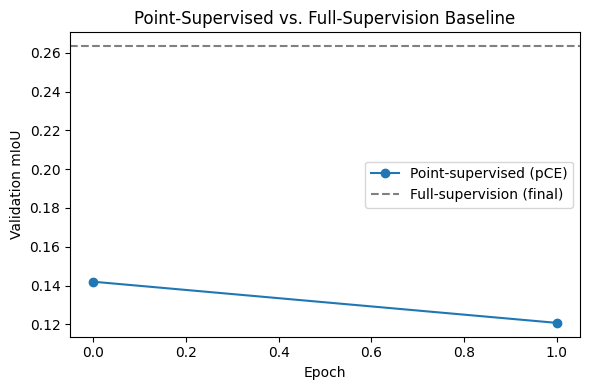

In [12]:
plt.figure(figsize=(6,4))
plt.plot(history_points.val_miou, label="Point-supervised (pCE)", marker="o")
plt.axhline(y=meter.mean_iou(), color="gray", linestyle="--", label="Full-supervision (final)")
plt.xlabel("Epoch"); plt.ylabel("Validation mIoU")
plt.title("Point-Supervised vs. Full-Supervision Baseline")
plt.legend(); plt.tight_layout(); plt.show()


## 6. Experiment A — Point Density

Trains a fresh model for each points-per-class budget and compares validation mIoU.
**Hypothesis:** mIoU rises steeply at low point counts and plateaus as it
approaches the full-supervision upper bound.

> Reduce `EPOCHS`/`point_counts` further for a quick notebook run; use the full
> range for the actual report results.


In [13]:
exp_config = TrainConfig(epochs=3, lr=1e-3, batch_size=BATCH_SIZE, num_workers=0, device=train_config.device)

df_density = run_point_density_experiment(
    train_tiles, val_tiles,
    point_counts=[5, 20, 50, 100],
    strategy="random",
    train_config=exp_config,
    encoder_name=ENCODER,
    seed=0,
)
df_density



=== Experiment A: 5 points/class, strategy=random ===
    batch 20/68  loss=0.9823
    batch 40/68  loss=0.8554
    batch 60/68  loss=0.8687
Epoch   1/3  train_loss=0.9991  val_mIoU=0.1637  val_pixAcc=0.4583  (47.3s)
    batch 20/68  loss=0.8103
    batch 40/68  loss=0.9308
    batch 60/68  loss=0.7032
Epoch   2/3  train_loss=0.8340  val_mIoU=0.1946  val_pixAcc=0.4412  (46.7s)
    batch 20/68  loss=0.9509
    batch 40/68  loss=0.6911
    batch 60/68  loss=0.9298
Epoch   3/3  train_loss=0.7536  val_mIoU=0.2079  val_pixAcc=0.4973  (46.9s)

=== Experiment A: 20 points/class, strategy=random ===
    batch 20/68  loss=1.0748
    batch 40/68  loss=0.9272
    batch 60/68  loss=0.8802
Epoch   1/3  train_loss=0.9756  val_mIoU=0.2305  val_pixAcc=0.5290  (47.4s)
    batch 20/68  loss=0.7874
    batch 40/68  loss=0.8225
    batch 60/68  loss=0.6285
Epoch   2/3  train_loss=0.8136  val_mIoU=0.1666  val_pixAcc=0.4707  (46.9s)
    batch 20/68  loss=0.9465
    batch 40/68  loss=0.8285
    batch 60/68 

,points_per_class,final_train_loss,val_mIoU,val_pixel_acc,best_val_mIoU
0,5,0.753621,0.207854,0.497307,0.207854
1,20,0.718002,0.301114,0.622359,0.301114
2,50,0.658494,0.302525,0.630822,0.302525
3,100,0.671698,0.297473,0.601398,0.297473


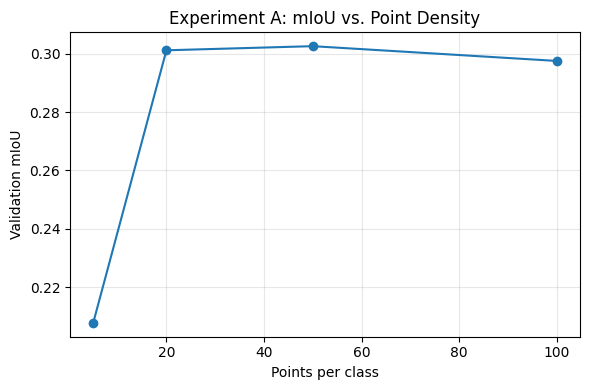

Saved experiment_A_point_density_results.csv


In [14]:
plt.figure(figsize=(6,4))
plt.plot(df_density["points_per_class"], df_density["val_mIoU"], marker="o")
plt.xlabel("Points per class"); plt.ylabel("Validation mIoU")
plt.title("Experiment A: mIoU vs. Point Density")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

df_density.to_csv("../experiment_A_point_density_results.csv", index=False)
print("Saved experiment_A_point_density_results.csv")


## 7. Experiment B — Sampling Strategy

Compares **class-balanced** stratified point sampling vs. **pixel-proportional**
random sampling at a matched total annotation budget, reporting **per-class IoU**.
**Hypothesis:** class-balanced sampling disproportionately helps minority classes
(e.g. urban land, water, barren land) relative to the dominant classes
(agriculture, forest) that DeepGlobe over-represents.


In [15]:
df_strategy = run_sampling_strategy_experiment(
    train_tiles, val_tiles,
    n_points=20,
    strategies=["class_balanced", "pixel_proportional"],
    train_config=exp_config,
    encoder_name=ENCODER,
    seed=0,
)
df_strategy



=== Experiment B: strategy=class_balanced, 20 points/class ===
    batch 20/68  loss=0.9655
    batch 40/68  loss=0.9627
    batch 60/68  loss=0.8672
Epoch   1/3  train_loss=0.9793  val_mIoU=0.1290  val_pixAcc=0.4079  (47.4s)
    batch 20/68  loss=0.7408
    batch 40/68  loss=0.7863
    batch 60/68  loss=0.6590
Epoch   2/3  train_loss=0.8064  val_mIoU=0.2075  val_pixAcc=0.5099  (46.4s)
    batch 20/68  loss=0.9253
    batch 40/68  loss=0.6922
    batch 60/68  loss=0.9160
Epoch   3/3  train_loss=0.6977  val_mIoU=0.2737  val_pixAcc=0.5959  (47.0s)

=== Experiment B: strategy=pixel_proportional, 20 points/class ===
    batch 20/68  loss=0.7150
    batch 40/68  loss=0.4199
    batch 60/68  loss=0.8060
Epoch   1/3  train_loss=0.6896  val_mIoU=0.1721  val_pixAcc=0.5263  (44.3s)
    batch 20/68  loss=0.4275
    batch 40/68  loss=0.6279
    batch 60/68  loss=0.2957
Epoch   2/3  train_loss=0.5446  val_mIoU=0.2335  val_pixAcc=0.6822  (44.4s)
    batch 20/68  loss=0.5068
    batch 40/68  loss=0.

,strategy,class_name,iou
0,class_balanced,Urban land,0.204800
1,class_balanced,Agriculture land,0.574359
2,class_balanced,Rangeland,0.108033
3,class_balanced,Forest land,0.501553
4,class_balanced,Water,0.184114
5,class_balanced,Barren land,0.069612
6,class_balanced,MEAN (mIoU),0.273745
7,pixel_proportional,Urban land,0.147833
8,pixel_proportional,Agriculture land,0.697692
9,pixel_proportional,Rangeland,0.008641


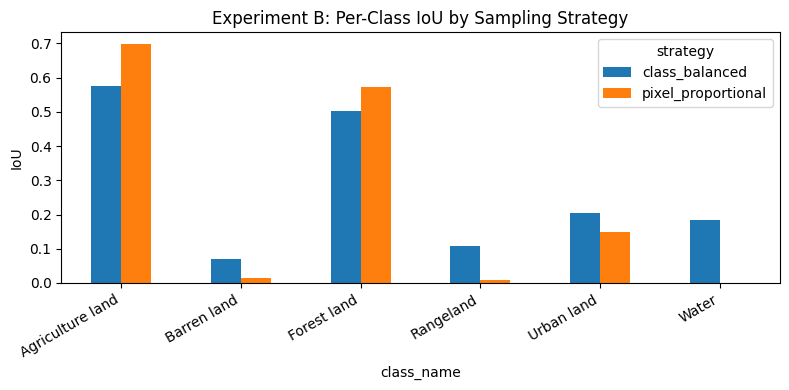

Saved experiment_B_sampling_strategy_results.csv


In [18]:
pivot = df_strategy[df_strategy["class_name"] != "MEAN (mIoU)"].pivot(
    index="class_name", columns="strategy", values="iou"
)
pivot.plot(kind="bar", figsize=(8, 4))
plt.ylabel("IoU"); plt.title("Experiment B: Per-Class IoU by Sampling Strategy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

# Change this line:
df_strategy.to_csv("experiment_B_sampling_strategy_results.csv", index=False)

print("Saved experiment_B_sampling_strategy_results.csv")


## 8. Qualitative Predictions

Visual side-by-side of image / ground truth / point-supervised prediction on a
few validation tiles.


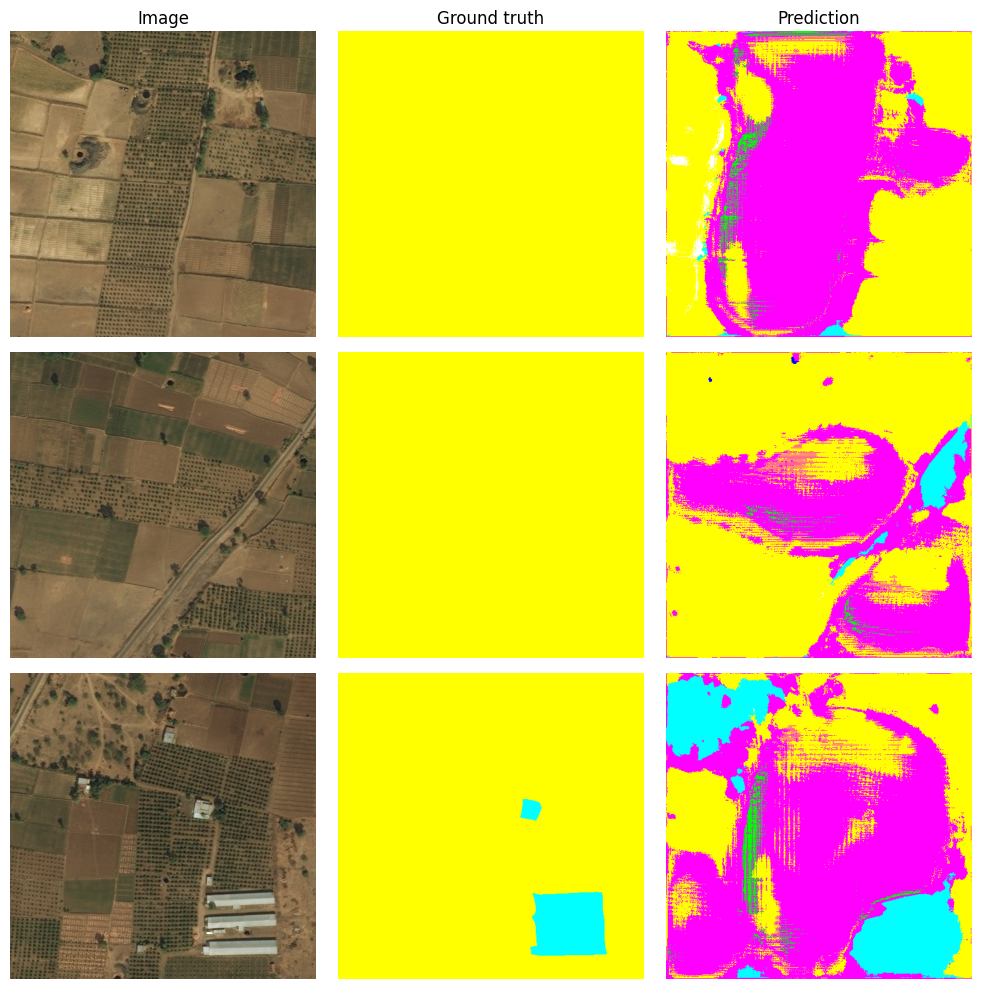

In [19]:
model_points.eval()
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
device = train_config.device

for row in range(3):
    img_t, label_t = val_ds[row]
    with torch.no_grad():
        pred = model_points(img_t.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu().numpy()

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    axes[row, 0].imshow(img_np); axes[row, 0].set_title("Image" if row == 0 else ""); axes[row, 0].axis("off")
    axes[row, 1].imshow(class_id_to_rgb_mask(label_t.numpy())); axes[row, 1].set_title("Ground truth" if row == 0 else ""); axes[row, 1].axis("off")
    axes[row, 2].imshow(class_id_to_rgb_mask(pred)); axes[row, 2].set_title("Prediction" if row == 0 else ""); axes[row, 2].axis("off")

plt.tight_layout(); plt.show()


## 9. Summary

- `history_points` / `meter` (full-sup) hold the headline point-supervised vs.
  full-supervision comparison used in the technical report.
- `experiment_A_point_density_results.csv` and
  `experiment_B_sampling_strategy_results.csv` hold the ablation results — these
  feed directly into the "Results" subsections of `technical_report.md`.
- Swap `USE_SYNTHETIC_DATA = False` + real `DATA_ROOT`, raise `EPOCHS` and
  `TILE_SIZE=512`, and re-run this notebook top-to-bottom to produce the final
  numbers for submission.
